แสดงชื่อ ขนาดและจำนวนไฟล์  ".txt "ทั้งหมดในทุกโฟลเดอร์ย่อยของโฟลเดอร์ Soil พร้อมแสดงโฟเดอร์ย่อยที่จัดเก็บไฟล์

In [1]:
import os

def scan_txt_files(folder_path):
    for root, _, files in os.walk(folder_path):
        for file_name in files:
            if file_name.endswith(".txt"):
                file_path = os.path.join(root, file_name)
                print("-" * 50)
                # เปิดไฟล์ .txt เพื่ออ่านข้อมูล
                with open(file_path, "r", encoding="utf-8") as file:
                    lines = file.readlines()
                    
                    # แสดงข้อมูลที่คุณต้องการ
                    num_rows = len(lines)
                    num_columns = len(lines[0].split()) if num_rows > 0 else 0
                    header = lines[0].strip() if num_rows > 0 else None
                    
                    print(f"ไฟล์: {file_name}")
                    if header:
                        print(f"หัวเรื่อง: {header}")
                    print(f"จำนวนแถว: {num_rows}")
                    print(f"จำนวนคอลัมน์: {num_columns}")
                    print(f"ที่อยู่ของไฟล์: {file_path}")  # เพิ่มแถวนี้เพื่อแสดงที่อยู่ของไฟล์
                    print("\n")

# ระบุโฟลเดอร์หลักที่คุณต้องการสแกน
main_folder = "Soil"
scan_txt_files(main_folder)


--------------------------------------------------
ไฟล์: Soil_KunNoR2.txt
หัวเรื่อง: Soil_KB_No Reagent:10/10/2023,19:34:00
จำนวนแถว: 681
จำนวนคอลัมน์: 2
ที่อยู่ของไฟล์: Soil/Kun/Soil_KunNoR2.txt


--------------------------------------------------
ไฟล์: Soil_KunNoR1.txt
หัวเรื่อง: Soil_kunrakaNo Reagent:10/10/2023,05:44:15
จำนวนแถว: 681
จำนวนคอลัมน์: 2
ที่อยู่ของไฟล์: Soil/Kun/Soil_KunNoR1.txt


--------------------------------------------------
ไฟล์: Soil_Kunblank.txt
หัวเรื่อง: Soil_kunrakablank:10/10/2023,05:29:25
จำนวนแถว: 681
จำนวนคอลัมน์: 1
ที่อยู่ของไฟล์: Soil/Kun/Soil_Kunblank.txt


--------------------------------------------------
ไฟล์: Soil_KunN1.txt
หัวเรื่อง: Soil_KN_No Reagent:10/10/2023,20:11:04
จำนวนแถว: 681
จำนวนคอลัมน์: 2
ที่อยู่ของไฟล์: Soil/Kun/Soil_KunN1.txt


--------------------------------------------------
ไฟล์: Soil_KunN2.txt
หัวเรื่อง: Soil_KN_N Reagent:10/10/2023,21:35:13
จำนวนแถว: 681
จำนวนคอลัมน์: 2
ที่อยู่ของไฟล์: Soil/Kun/Soil_KunN2.txt


--------------

แปลงไฟล์ txt ในแต่ละโฟลเดอร์  เป็น cvs   และบันทึกไว้ในโฟลเดอร์  SdatasetCSV 

In [2]:
import os
import csv

# ระบุโฟลเดอร์หลัก N_raw
main_folder = "Soil"

# ระบุโฟลเดอร์ที่จะบันทึกไฟล์ .csv
output_folder_path = "Soil/SdatasetCSV"

# ตรวจสอบว่าโฟลเดอร์ output_folder_path มีอยู่หรือไม่ และสร้างถ้าไม่มี
if not os.path.exists(output_folder_path):
    os.makedirs(output_folder_path)

# วนลูปผ่านโฟลเดอร์และไฟล์ทั้งหมดในโฟลเดอร์หลัก
for root, _, files in os.walk(main_folder):
    for filename in files:
        if filename.endswith(".txt"):
            # รับที่อยู่ของไฟล์ .txt
            input_file_path = os.path.join(root, filename)
            
            # สร้างชื่อไฟล์ .csv ใหม่โดยนำชื่อไฟล์เดิมมาใช้
            output_file_path = os.path.join(output_folder_path, os.path.splitext(filename)[0] + ".csv")

            # เปิดไฟล์ .txt สำหรับอ่าน
            with open(input_file_path, "r") as txt_file:
                # อ่านข้อมูลทั้งหมดจากไฟล์ .txt
                lines = txt_file.readlines()

            # ตรวจสอบว่ามีข้อมูลในไฟล์หรือไม่
            if len(lines) > 0:
                # ลบข้อมูลในแถวแรก
                lines = lines[1:]

                # เปิดไฟล์ .csv สำหรับเขียน
                with open(output_file_path, "w", newline='') as csv_file:
                    # สร้างอ็อบเจ็กต์ writer สำหรับเขียนข้อมูล CSV
                    csv_writer = csv.writer(csv_file)

                    # เขียนข้อมูลลงในไฟล์ .csv
                    for line in lines:
                        # แบ่งข้อมูลในแต่ละบรรทัดด้วยเครื่องหมาย "," และลบช่องว่างด้านหน้าและหลัง
                        row_data = line.strip().split(",")
                        csv_writer.writerow(row_data)

            print(f"แปลงไฟล์ '{filename}' และบันทึกเป็น '{os.path.basename(output_file_path)}'")

print("เสร็จสิ้นการแปลงไฟล์ .txt เป็น .csv และบันทึกในโฟลเดอร์ SdatasetCSV")


แปลงไฟล์ 'Soil_KunNoR2.txt' และบันทึกเป็น 'Soil_KunNoR2.csv'
แปลงไฟล์ 'Soil_KunNoR1.txt' และบันทึกเป็น 'Soil_KunNoR1.csv'
แปลงไฟล์ 'Soil_Kunblank.txt' และบันทึกเป็น 'Soil_Kunblank.csv'
แปลงไฟล์ 'Soil_KunN1.txt' และบันทึกเป็น 'Soil_KunN1.csv'
แปลงไฟล์ 'Soil_KunN2.txt' และบันทึกเป็น 'Soil_KunN2.csv'
แปลงไฟล์ 'Soil_KunP2.txt' และบันทึกเป็น 'Soil_KunP2.csv'
แปลงไฟล์ 'Soil_KunP1.txt' และบันทึกเป็น 'Soil_KunP1.csv'
แปลงไฟล์ 'Soil_SomN1.txt' และบันทึกเป็น 'Soil_SomN1.csv'
แปลงไฟล์ 'Soil_SomN2.txt' และบันทึกเป็น 'Soil_SomN2.csv'
แปลงไฟล์ 'Soil_Somblank.txt' และบันทึกเป็น 'Soil_Somblank.csv'
แปลงไฟล์ 'Soil_SomP2.txt' และบันทึกเป็น 'Soil_SomP2.csv'
แปลงไฟล์ 'Soil_SomP1.txt' และบันทึกเป็น 'Soil_SomP1.csv'
แปลงไฟล์ 'Soil_SomNoR2.txt' และบันทึกเป็น 'Soil_SomNoR2.csv'
แปลงไฟล์ 'Soil_SomNoR1.txt' และบันทึกเป็น 'Soil_SomNoR1.csv'
แปลงไฟล์ 'Soil_Banblank.txt' และบันทึกเป็น 'Soil_Banblank.csv'
แปลงไฟล์ 'Soil_BanN2.txt' และบันทึกเป็น 'Soil_BanN2.csv'
แปลงไฟล์ 'Soil_BanN1.txt' และบันทึกเป็น 'Soil_BanN1.cs

เลื่อนข้อมูลในคอลัมน์ 'Intensity' ขึ้นหนึ่งแถว และลบแถวที่มีคอลัมน์ 'Order' เท่ากับ 0 และคอลัมน์ 'Color' เท่ากับ 'Black' หลังจากนั้นบันทึกข้อมูลที่แก้ไขแล้วในไฟล์ .csv 

In [3]:
import os
import pandas as pd

# Define the column names
column_names = ["No.", "Order", "Color", "Intensity"]

# Specify the folder path
folder_path = "Soil/SdatasetCSV"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Load the CSV file with the specified column names
    df = pd.read_csv(file_path, names=column_names)

    # Shift the data in the 'Intensity' column up by one row
    df['Intensity'] = df['Intensity'].shift(-1)

    # Drop rows where 'Order' is equal to 0 and 'Color' is equal to 'Black'
    df = df[(df['Order'] != 0) | (df['Color'] != 'Black')]

    # Specify the original file path and save the modified DataFrame
    df.to_csv(file_path, index=False)

    # Print a confirmation message for each file
    print(f"Modified DataFrame saved to {file_path}")

print("All CSV files in the 'SdatasetCSV' folder have been processed.")


Modified DataFrame saved to Soil/SdatasetCSV/Soil_Kunblank.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_KunN2.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_BanN1.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_KunN1.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_BanN2.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_KunP1.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_SomNoR1.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_BanP2.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_KunP2.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_SomNoR2.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_BanP1.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_BanNoR2.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_BanNoR1.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_PatP2.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_SomN2.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_PatP1.csv
Modified DataFrame saved to S

In [4]:
import os
import pandas as pd

# Specify the folder path
folder_path = "Soil/SdatasetCSV"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Load the CSV file
    df = pd.read_csv(file_path)

    # Remove the last row from the DataFrame
    df = df.iloc[:-1]

    # Save the modified DataFrame back to the same file
    df.to_csv(file_path, index=False)

    # Print a confirmation message for each file
    print(f"Last row removed and file '{csv_file}' saved with the same name.")

print("All CSV files in the 'SdatasetCSV' folder have had their last row removed and saved with the same name.")


Last row removed and file 'Soil_Kunblank.csv' saved with the same name.
Last row removed and file 'Soil_KunN2.csv' saved with the same name.
Last row removed and file 'Soil_BanN1.csv' saved with the same name.
Last row removed and file 'Soil_KunN1.csv' saved with the same name.
Last row removed and file 'Soil_BanN2.csv' saved with the same name.
Last row removed and file 'Soil_KunP1.csv' saved with the same name.
Last row removed and file 'Soil_SomNoR1.csv' saved with the same name.
Last row removed and file 'Soil_BanP2.csv' saved with the same name.
Last row removed and file 'Soil_KunP2.csv' saved with the same name.
Last row removed and file 'Soil_SomNoR2.csv' saved with the same name.
Last row removed and file 'Soil_BanP1.csv' saved with the same name.
Last row removed and file 'Soil_BanNoR2.csv' saved with the same name.
Last row removed and file 'Soil_BanNoR1.csv' saved with the same name.
Last row removed and file 'Soil_PatP2.csv' saved with the same name.
Last row removed and fi

In [5]:
import os

# ระบุโฟลเดอร์หลักที่คุณต้องการทำการสแกน (เช่น 'N_raw')
main_folder = 'Soil'

# ฟังก์ชันสำหรับแสดงข้อมูลจากไฟล์ .txt และเพิ่มบรรทัดว่างหลังจากแต่ละไฟล์
def display_txt_file_contents(root, files):
    for file in files:
        if file.endswith(".txt"):
            file_path = os.path.join(root, file)
            print(f"ไฟล์: {file_path}")
            with open(file_path, 'r', encoding='utf-8') as txt_file:
                lines = txt_file.readlines()
                for line in lines:
                    print(line.strip())  # แสดงข้อมูลของแต่ละไลน์ในไฟล์
            print("\n" + "=" * 50 + "\n")  # เพิ่มบรรทัดว่างหลังจากแต่ละไฟล์

# เรียกใช้ฟังก์ชันเพื่อทำงาน
if os.path.exists(main_folder):
    for root, dirs, files in os.walk(main_folder):
        display_txt_file_contents(root, files)
else:
    print(f"โฟลเดอร์ '{main_folder}' ไม่พบ")


ไฟล์: Soil/Kun/Soil_KunNoR2.txt
Soil_KB_No Reagent:10/10/2023,19:34:00
1,1,White,4
2,2,White,90
3,3,White,95
4,4,White,92
5,5,White,97
6,6,White,92
7,7,White,93
8,8,White,93
9,9,White,92
10,10,White,97
11,11,White,91
12,12,White,97
13,13,White,94
14,14,White,93
15,15,White,94
16,16,White,93
17,17,White,96
18,18,White,96
19,19,White,92
20,20,White,92
21,21,White,95
22,22,White,94
23,23,White,92
24,24,White,92
25,25,White,94
26,26,White,90
27,27,White,92
28,28,White,96
29,29,White,95
30,1,Red,90
31,2,Red,60
32,3,Red,56
33,4,Red,57
34,5,Red,57
35,6,Red,61
36,7,Red,58
37,8,Red,56
38,9,Red,58
39,10,Red,58
40,11,Red,59
41,12,Red,59
42,13,Red,58
43,14,Red,61
44,15,Red,60
45,16,Red,60
46,17,Red,57
47,18,Red,61
48,19,Red,61
49,20,Red,61
50,21,Red,59
51,22,Red,57
52,23,Red,59
53,24,Red,59
54,25,Red,55
55,26,Red,60
56,27,Red,56
57,28,Red,58
58,29,Red,57
59,30,Red,59
60,1,Green,58
61,2,Green,29
62,3,Green,28
63,4,Green,29
64,5,Green,28
65,6,Green,30
66,7,Green,30
67,8,Green,33
68,9,Green,33
69,10,

In [6]:
import os
import pandas as pd

# Specify the folder path
folder_path = "Soil/SdatasetCSV"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Load the CSV file
    df = pd.read_csv(file_path)

    # Convert the 'Intensity' column to integers
    df['Intensity'] = df['Intensity'].astype(int)

    # Save the modified DataFrame back to the CSV file
    df.to_csv(file_path, index=False)

    # Print a confirmation message for each file
    print(f"Modified DataFrame saved to {file_path}")

print("All CSV files in the 'SdatasetCSV' folder have been processed.")


Modified DataFrame saved to Soil/SdatasetCSV/Soil_Kunblank.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_KunN2.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_BanN1.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_KunN1.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_BanN2.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_KunP1.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_SomNoR1.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_BanP2.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_KunP2.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_SomNoR2.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_BanP1.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_BanNoR2.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_BanNoR1.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_PatP2.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_SomN2.csv
Modified DataFrame saved to Soil/SdatasetCSV/Soil_PatP1.csv
Modified DataFrame saved to S

In [7]:
import os
import pandas as pd

# Specify the folder path
folder_path = "Soil/SdatasetCSV"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# Iterate through each CSV file and process it
for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Filter and remove rows where 'Order' is in the specified values (1,2,3,4,5,25,26, 27, 28, 29, 30)
    df = df[~df['Order'].isin([25,26, 27, 28, 29, 30])]

    # Save the modified DataFrame back to the same file
    df.to_csv(file_path, index=False)

    # Report the file name and the number of rows after the removal
    print(f"File: {csv_file}, Rows After Removal: {len(df)}")


File: Soil_Kunblank.csv, Rows After Removal: 480
File: Soil_KunN2.csv, Rows After Removal: 480
File: Soil_BanN1.csv, Rows After Removal: 480
File: Soil_KunN1.csv, Rows After Removal: 480
File: Soil_BanN2.csv, Rows After Removal: 480
File: Soil_KunP1.csv, Rows After Removal: 480
File: Soil_SomNoR1.csv, Rows After Removal: 479
File: Soil_BanP2.csv, Rows After Removal: 480
File: Soil_KunP2.csv, Rows After Removal: 480
File: Soil_SomNoR2.csv, Rows After Removal: 480
File: Soil_BanP1.csv, Rows After Removal: 480
File: Soil_BanNoR2.csv, Rows After Removal: 480
File: Soil_BanNoR1.csv, Rows After Removal: 480
File: Soil_PatP2.csv, Rows After Removal: 480
File: Soil_SomN2.csv, Rows After Removal: 480
File: Soil_PatP1.csv, Rows After Removal: 480
File: Soil_SomN1.csv, Rows After Removal: 480
File: Soil_Patblank.csv, Rows After Removal: 479
File: Soil_PatNoR1.csv, Rows After Removal: 480
File: Soil_PatNoR2.csv, Rows After Removal: 480
File: Soil_Banblank.csv, Rows After Removal: 480
File: Soil_Pa

# เขียนกราฟ

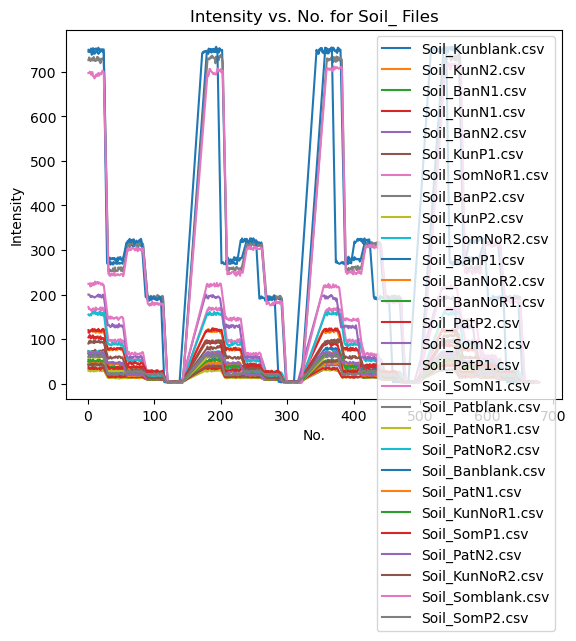

In [8]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Specify the folder path
folder_path = "Soil/SdatasetCSV"

# List all CSV files in the folder starting with "N2_"
csv_files = [f for f in os.listdir(folder_path) if f.startswith("Soil_") and f.endswith(".csv")]

# Create a DataFrame to store data from all "N2_" files
combined_df = pd.DataFrame()

# Iterate through the "N2_" files and plot their data
for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Load the CSV file
    df = pd.read_csv(file_path)

    # Plot the data for each "N2_" file
    plt.plot(df['No.'], df['Intensity'], label=csv_file)

    # Append the data to the combined DataFrame
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Set labels and title for the plot
plt.xlabel("No.")
plt.ylabel("Intensity")
plt.title("Intensity vs. No. for Soil_ Files")

# Show legend for each "N2_" file
plt.legend()

# Show the plot
plt.show()

# If you want to save the combined data to a CSV file, you can use:
# combined_df.to_csv("combined_data.csv", index=False)


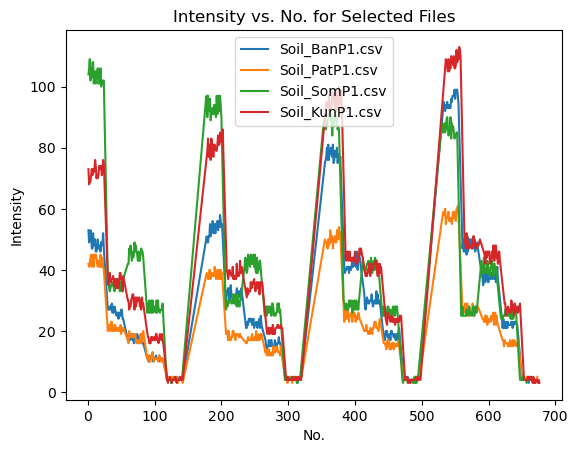

In [9]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Specify the folder path
folder_path = "Soil/SdatasetCSV"

# List of file names to include in the graph
#file_names = [f"N{i}_NoR.csv" for i in [2, 4, 6, 8, 10]]

file_names = ["Soil_BanP1.csv", "Soil_PatP1.csv", "Soil_SomP1.csv", "Soil_KunP1.csv"]

# Create a DataFrame to store data from selected files
combined_df = pd.DataFrame()

# Iterate through the selected files and plot their data
for csv_file in file_names:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Load the CSV file
    df = pd.read_csv(file_path)

    # Plot the data for each selected file
    plt.plot(df['No.'], df['Intensity'], label=csv_file)

    # Append the data to the combined DataFrame
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Set labels and title for the plot
plt.xlabel("No.")
plt.ylabel("Intensity")
plt.title("Intensity vs. No. for Selected Files")

# Show legend for each selected file
plt.legend()

# Show the plot
plt.show()

# If you want to save the combined data to a CSV file, you can use:
# combined_df.to_csv("combined_data.csv", index=False)


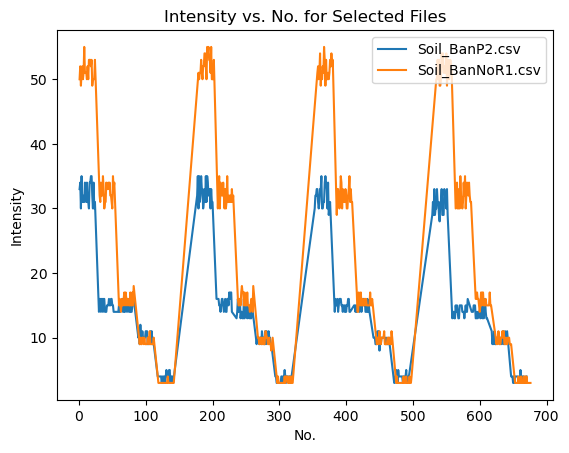

In [11]:
import os
import pandas as pd
import matplotlib.pyplot as plt

# Specify the folder path
folder_path = "Soil/SdatasetCSV"

# List of file names to include in the graph
file_names = ["Soil_BanP2.csv", "Soil_BanNoR1.csv"]

# Create a DataFrame to store data from selected files
combined_df = pd.DataFrame()

# Iterate through the selected files and plot their data
for csv_file in file_names:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Load the CSV file
    df = pd.read_csv(file_path)

    # Plot the data for each selected file
    plt.plot(df['No.'], df['Intensity'], label=csv_file)

    # Append the data to the combined DataFrame
    combined_df = pd.concat([combined_df, df], ignore_index=True)

# Set labels and title for the plot
plt.xlabel("No.")
plt.ylabel("Intensity")
plt.title("Intensity vs. No. for Selected Files")

# Show legend for each selected file
plt.legend()

# Show the plot
plt.show()

# If you want to save the combined data to a CSV file, you can use:
# combined_df.to_csv("combined_data.csv", index=False)


โค๊ดคำนวณค่าเฉลี่ยและส่วนเบี่บงเบนมาตรฐานของ Intensity ของทุกไฟล์ในโฟลเดอร์ NdatasetCSV

# บันทึกไฟล์รวมข้อมูล ค่าเฉลี่ยและส่วนเบี่ยงเบนมาตราฐานของไฟล์ในโฟลเดอร์  SdatasetCSV  บันทึกเป็นชื่อ  S_Mean.csv  และ S_StdDeV.csv  ในโฟลเดอร์ StandardData

In [12]:
import os
import pandas as pd

# Specify the folder path
folder_path = "Soil/SdatasetCSV"

# List all CSV files in the folder
csv_files = [f for f in os.listdir(folder_path) if f.endswith(".csv")]

# Create empty DataFrames to store the calculated statistics
average_intensity_df = pd.DataFrame()
std_dev_intensity_df = pd.DataFrame()

# Loop through each CSV file and calculate statistics for 'Intensity' column
for csv_file in csv_files:
    # Construct the full file path
    file_path = os.path.join(folder_path, csv_file)

    # Read the CSV file into a DataFrame
    df = pd.read_csv(file_path)

    # Check if 'Intensity' column exists in the DataFrame
    if 'Intensity' in df.columns:
        # Group data by 'Order' and 'Color' columns, then calculate mean and standard deviation
        grouped_data = df.groupby(['Order', 'Color'])['Intensity']
        mean_intensity = grouped_data.mean()
        std_dev_intensity = grouped_data.std()

        # Combine the calculated statistics into the DataFrames
        average_intensity_df[csv_file] = mean_intensity
        std_dev_intensity_df[csv_file] = std_dev_intensity
    else:
        print(f"Intensity column not found in file: {csv_file}")

# Save the calculated statistics as CSV files
output_folder = "StandardData"
output_mean_filename = "S_Mean.csv"
output_stddev_filename = "S_StdDev.csv"
output_mean_path = os.path.join(output_folder, output_mean_filename)
output_stddev_path = os.path.join(output_folder, output_stddev_filename)

# Create the "StandardData" folder if it doesn't exist
os.makedirs(output_folder, exist_ok=True)

# Save the DataFrames as CSV files
average_intensity_df.to_csv(output_mean_path)
std_dev_intensity_df.to_csv(output_stddev_path)

# Print the calculated statistics
print("Average Intensity Values:")
print(average_intensity_df)

print("\nStandard Deviation of Intensity Values:")
print(std_dev_intensity_df)

print(f"Calculated statistics saved to {output_mean_path} and {output_stddev_path}")


Average Intensity Values:
             Soil_Kunblank.csv  Soil_KunN2.csv  Soil_BanN1.csv  \
Order Color                                                      
1     Black               3.75            5.25            4.00   
      Blue              192.25           16.00            9.50   
      Green             314.00           36.25           13.50   
      Red               276.75           77.75           26.25   
      White             748.00          116.25           42.75   
...                        ...             ...             ...   
24    Black               3.00            5.00            4.25   
      Blue              193.75           15.25            9.25   
      Green             313.75           36.00           13.75   
      Red               280.25           76.50           26.50   
      White             750.00          119.25           41.00   

             Soil_KunN1.csv  Soil_BanN2.csv  Soil_KunP1.csv  Soil_SomNoR1.csv  \
Order Color                       

# ปรับแต่งหัวตาราง

In [13]:
import pandas as pd

# Function to remove ".csv" from column names and save the modified DataFrame
def remove_csv_extension_and_save(filename):
    # Read the CSV file into a DataFrame
    df = pd.read_csv(filename)

    # Remove the ".csv" from column names
    df.columns = [col.replace('.csv', '') for col in df.columns]

    # Save the modified DataFrame back to the original file
    df.to_csv(filename, index=False)

# List of files to process
file_list = ["StandardData/S_mean.csv", "StandardData/S_stddev.csv"]

# Process each file
for file in file_list:
    remove_csv_extension_and_save(file)
    print(f"Updated {file} with modified column names.")


Updated StandardData/S_mean.csv with modified column names.
Updated StandardData/S_stddev.csv with modified column names.


เปิดไฟล์ N_mean.csv เพื่อดูข้อมูล

In [14]:
import pandas as pd

# Read the "N_mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/S_mean.csv")

# Display the DataFrame
print(df)


     Order  Color  Soil_Kunblank  Soil_KunN2  Soil_BanN1  Soil_KunN1  \
0        1  Black           3.75        5.25        4.00        5.00   
1        1   Blue         192.25       16.00        9.50       16.25   
2        1  Green         314.00       36.25       13.50       37.25   
3        1    Red         276.75       77.75       26.25       77.75   
4        1  White         748.00      116.25       42.75      119.00   
..     ...    ...            ...         ...         ...         ...   
115     24  Black           3.00        5.00        4.25        5.25   
116     24   Blue         193.75       15.25        9.25       16.25   
117     24  Green         313.75       36.00       13.75       36.25   
118     24    Red         280.25       76.50       26.50       76.25   
119     24  White         750.00      119.25       41.00      119.25   

     Soil_BanN2  Soil_KunP1  Soil_SomNoR1  Soil_BanP2  ...  Soil_PatNoR1  \
0          4.00        4.00      3.250000        4.00  ... 

In [15]:
import pandas as pd
import os

# Read the "N_mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/S_mean.csv")

# Calculate the average of the columns following the "Color" column
# Group the data by the "Color" column and calculate the mean
average_by_color = df.groupby("Color").mean()

# Display the result
print("Average by Color:")
print(average_by_color)

# Define the output file path
output_folder = "StandardData"
output_filename = "S_all_Mean.csv"
output_path = os.path.join(output_folder, output_filename)

# Check if the file "N_all_Mean.csv" already exists
if os.path.exists(output_path):
    print(f"'{output_filename}' already exists. Overwriting the file.")

# Save the DataFrame to a CSV file
average_by_color.to_csv(output_path)

print(f"Data saved to '{output_path}' as 'S_all_Mean.csv'.")


Average by Color:
       Order  Soil_Kunblank  Soil_KunN2  Soil_BanN1  Soil_KunN1  Soil_BanN2  \
Color                                                                         
Black   12.5       3.302083    5.145833    4.000000    5.135417    3.989583   
Blue    12.5     192.218750   15.531250    9.177083   15.552083    9.750000   
Green   12.5     313.520833   36.208333   13.895833   36.937500   15.416667   
Red     12.5     279.333333   76.770833   26.833333   77.593750   24.979167   
White   12.5     749.395833  117.760417   42.125000  119.729167   42.750000   

       Soil_KunP1  Soil_SomNoR1  Soil_BanP2  Soil_KunP2  ...  Soil_PatNoR1  \
Color                                                    ...                 
Black    4.083333      3.315972    3.760417    3.760417  ...      3.239583   
Blue    22.322917     23.104167    9.875000   11.375000  ...     16.843750   
Green   37.229167     54.604167   14.427083   15.697917  ...     22.343750   
Red     42.031250     95.822917   14.9

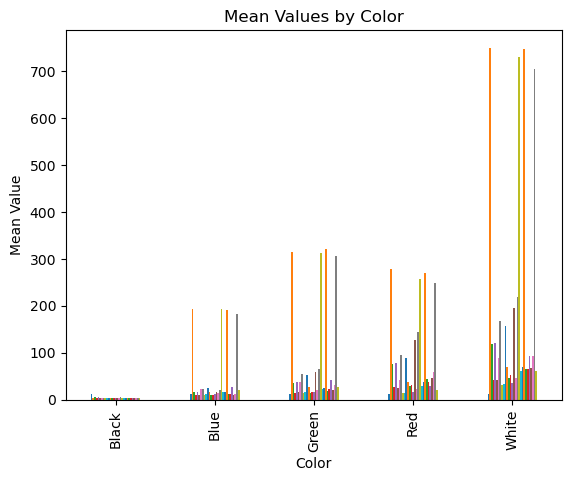

In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/S_all_Mean.csv")

# Plot a bar chart with "Color" on the x-axis and the mean values on the y-axis
df.plot(x="Color", kind="bar", legend=None)

# Set labels and title
plt.xlabel("Color")
plt.ylabel("Mean Value")
plt.title("Mean Values by Color")

# Show the plot
plt.show()


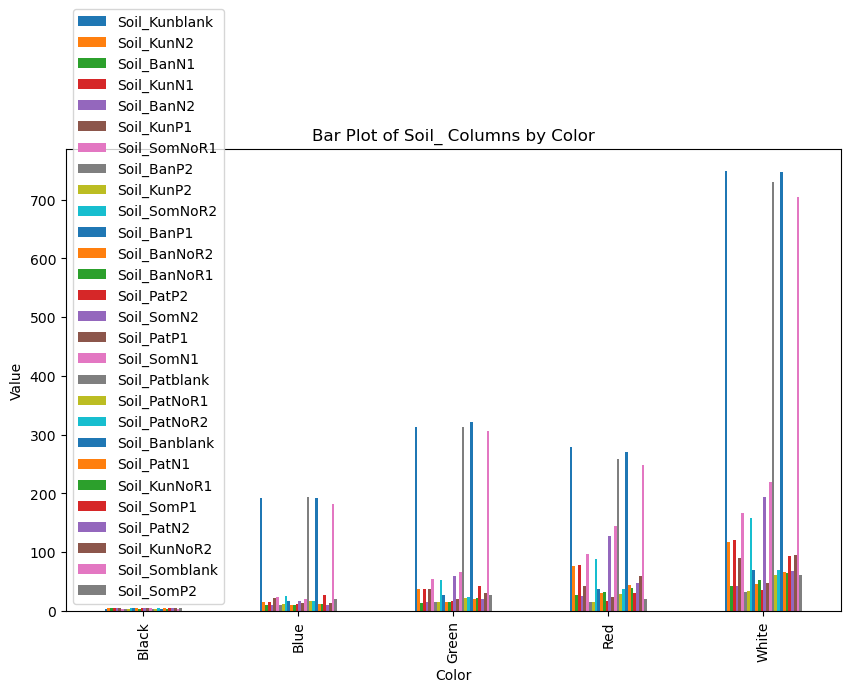

In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/S_all_Mean.csv")

# Filter columns that start with "N2_"
n2_columns = [col for col in df.columns if col.startswith("Soil_")]

# Set "Color" as the x-axis and "N2_" columns as the y-axis
df_plot = df[['Color'] + n2_columns]

# Set "Color" as the index for better plotting
df_plot = df_plot.set_index('Color')

# Create a bar plot
df_plot.plot(kind='bar', figsize=(10, 6))
plt.title("Bar Plot of Soil_ Columns by Color")
plt.xlabel("Color")
plt.ylabel("Value")

# Show the plot
plt.show()



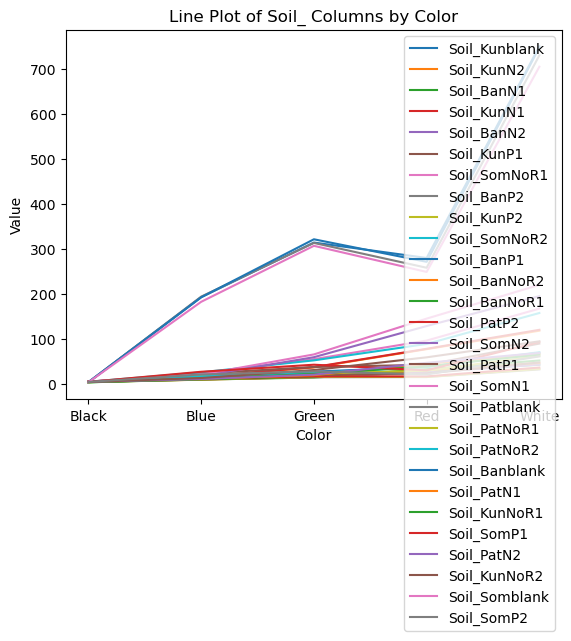

In [18]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/S_all_Mean.csv")

# Filter the columns starting with "N2_"
n2_columns = [col for col in df.columns if col.startswith("Soil_")]

# Set "Color" column as the x-axis
x = df["Color"]

# Plot each "N2_" column as a separate line
for col in n2_columns:
    y = df[col]
    plt.plot(x, y, label=col)

# Customize the plot
plt.xlabel("Color")
plt.ylabel("Value")
plt.title("Line Plot of Soil_ Columns by Color")
plt.legend(loc="upper right")

# Show the plot
plt.show()


In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Read the "N_all_Mean.csv" file into a DataFrame
df = pd.read_csv("StandardData/S_all_Mean.csv")
# Select the columns "Color," "N2_R," and "N2_WR"
df = df[["Color", "Soil_BanNoR1", "Soil_BanP1"]]

# Set "Color" column as the x-axis
x = df["Color"]

# Set the values of "N2_R" and "N2_WR" as the y-axis
y1 = df["Soil_BanNoR1"]
y2 = df["Soil_ฺBanP1"]

# Define the width of the bars
bar_width = 0.35

# Set the x positions for the bars
x_indexes = range(len(x))

# Plot the "N2_R" and "N2_WR" values as side-by-side bars
plt.bar(x_indexes, y1, width=bar_width, label="Soil_BanNoR1", align="center")
plt.bar(x_indexes, y2, width=bar_width, label="Soil_BanP2", align="edge")

# Customize the plot
plt.xlabel("Color")
plt.ylabel("Intensity")
plt.title("Bar Plot of Soil_BanNoR1 and Soil_BanP1 by Color")
plt.xticks(x_indexes, x, rotation=90)
plt.legend()

# Show the plot
plt.show()



KeyError: 'Soil_ฺBanP1'

In [ ]:
import pandas as pd

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/N_all_Mean.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# ระบุคอลัมน์ที่ต้องการดึงข้อมูล

columns_to_display = ["Color"] + [col for col in data.columns if any(col.startswith(f"N{i}_") for i in [20, 40, 60, 80, 100])]

# แสดงข้อมูลที่เลือกบนหน้าจอ
selected_data = data[columns_to_display]
print(selected_data)


In [ ]:
import pandas as pd

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/N_all_Mean.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# ระบุคอลัมน์ที่ต้องการดึงข้อมูล
selected_columns = [
    "Color",
    *[f"N{i}_{j}" for i in [20, 40, 60, 80, 100] for j in ["W", "NoR"]]
]

# ดึงและเรียงลำดับข้อมูลตามคอลัมน์ "Color"
selected_data = data[selected_columns].sort_values(by="Color")

# แสดงข้อมูลที่เรียงลำดับบนหน้าจอ
print(selected_data)


In [ ]:
# ระบุชื่อไฟล์ CSV ที่คุณต้องการบันทึก
output_file = "StandardData/N_LMean.csv"

# บันทึกข้อมูลลงในไฟล์ CSV
selected_data.to_csv(output_file, index=False)

print("บันทึกข้อมูลลงในไฟล์", output_file)


In [ ]:
import pandas as pd

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/N_LMean.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# ลบแถวที่ 0
data = data.drop(0)

# เลือกคอลัมน์ที่ต้องการคำนวณ
selected_columns = data.columns[1:]

# วนลูปเพื่อคำนวณผลต่างของแถวทุกแถว
for i in range(1, len(data)):
    row_i = data.iloc[i, 1:].values
    row_0 = data.iloc[0, 1:].values
    row_diff = row_i - row_0
    data.loc[i, selected_columns] = row_diff

# บันทึกข้อมูลที่อัปเดตแล้วลงในไฟล์ CSV ใหม่ (ไม่รวมดัชนีแถว)
output_file = "StandardData/NL_Absorpt.csv"
data.to_csv(output_file, index=False)

print("บันทึกข้อมูลลงในไฟล์", output_file)


In [ ]:
import pandas as pd

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NL_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# แสดงข้อมูลบนหน้าจอ
print(data)


In [ ]:
import pandas as pd

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NL_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างรายการของคอลัมน์ที่คุณต้องการคำนวณ
columns_to_calculate = [f"N{i}_W, N{i}_NoR" for i in [20, 40, 60, 80, 100]]



# สร้าง DataFrame ที่มีเฉพาะคอลัมน์ "Color"
result = data[["Color"]]


for cols in columns_to_calculate:
    col1, col2 = cols.split(', ')
    result[f"Absorp_{col1}_{col2}"] = abs((data[col1] - data[col2]) )* 100 / data[col1]

# แสดงผลตาราง
print(result)


In [ ]:
# ระบุชื่อไฟล์ CSV ที่คุณต้องการบันทึกผลลัพธ์
output_file = "StandardData/NL_Absorpt.csv"

# บันทึกผลลัพธ์ลงในไฟล์ CSV (ไม่รวมดัชนีแถว)
result.to_csv(output_file, index=False)

print("บันทึกผลลัพธ์ลงในไฟล์", output_file)


In [ ]:
import pandas as pd

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NL_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)


columns_to_rename = {
    f"Absorp_N{i}_WR_N{i}_B": str(i) for i in [20, 40, 60, 80, 100]
}

# เปลี่ยนชื่อคอลัมน์ใน DataFrame
#data = data.rename(columns=columns_to_rename)

#data = data.rename(columns={"Color": "Concentrate"})


data = data.rename(columns={"Color": "Concentrate"}).transpose()

data.to_csv("StandardData/NLT_Absorpt.csv", index=False)


# บันทึกไฟล์ทับไฟล์เดิม
data.to_csv(file_path, index=False)

# แสดงผล
print(data)


In [ ]:
import pandas as pd

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างคอลัมน์ "Concentrate" และใส่ข้อมูล
data.insert(0, "Concentrate", [0, 20, 40, 60, 80, 100])

# เปลี่ยนชื่อคอลัมน์
data = data.rename(columns={0: "Blue", 1: "Green", 2: "Red", 3: "White"})

# ลบข้อมูลในแถว 0
data = data.drop(0)

# บันทึกข้อมูลลงในไฟล์ CSV
data.to_csv(file_path, index=False)

# แสดงผลลัพธ์บนหน้าจอ
print(data)


In [ ]:
import pandas as pd

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# เปลี่ยนชื่อคอลัมน์
data = data.rename(columns={"0": "Blue"})
data = data.rename(columns={"1": "Green"})
data = data.rename(columns={"2": "Red"})
data = data.rename(columns={"3": "White"})

# บันทึกข้อมูลลงในไฟล์ CSV
data.to_csv(file_path, index=False)


In [ ]:
import pandas as pd

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# แสดงข้อมูลบนหน้าจอ
print(data)


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างกราฟย่อยแยกตามคอลัมน์ Blue, Green, Red, White
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(15, 4), sharey=True)
colors = ['b', 'g', 'r', 'black']  # สีของ Blue, Green, Red, White

# สร้างกราฟย่อยแยกตามคอลัมน์ Blue, Green, Red, White
for i, column in enumerate(["Blue", "Green", "Red", "White"]):
    ax = axes[i]
    ax.scatter(data["Concentrate"], data[column], c=colors[i], label=column)
    ax.set_xlabel("Concentrate (mg/L)")
    ax.set_ylabel("Absorptance (%)")
    ax.set_title(f"{column} Absorption")
    ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างกราฟ
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# สร้างกราฟ Blue
axs[0, 0].scatter(data['Concentrate'], data['Blue'], color='blue')
axs[0, 0].set_title('Blue Absorptance')
axs[0, 0].set_xlabel('Concentrate (mg/L)')
axs[0, 0].set_ylabel('Absorptance (%)')

# สร้างกราฟ Green
axs[0, 1].scatter(data['Concentrate'], data['Green'], color='green')
axs[0, 1].set_title('Green Absorptance')
axs[0, 1].set_xlabel('Concentrate (mg/L)')
axs[0, 1].set_ylabel('Absorptance (%)')

# สร้างกราฟ Red
axs[1, 0].scatter(data['Concentrate'], data['Red'], color='red')
axs[1, 0].set_title('Red Absorptance')
axs[1, 0].set_xlabel('Concentrate (mg/L)')
axs[1, 0].set_ylabel('Absorptance (%)')

# สร้างกราฟ White
axs[1, 1].scatter(data['Concentrate'], data['White'], color='black')
axs[1, 1].set_title('White Absorptance')
axs[1, 1].set_xlabel('Concentrate (mg/L)')
axs[1, 1].set_ylabel('Absorptance (%)')

# ปรับระยะห่างของกราฟ
plt.tight_layout()

# แสดงกราฟ
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างกราฟย่อย
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# กำหนดสี
colors = ['blue', 'green', 'red', 'lightgrey']

# ลูปเพื่อสร้างกราฟ
for i, column in enumerate(['Blue', 'Green', 'Red', 'White']):
    ax = axs[i//2, i%2]
    color = colors[i]

    # สร้างกราฟ
    ax.plot(data['Concentrate'], data[column], color=color)
    ax.set_title(f'{column}')
    ax.set_xlabel('Concentrate (mg/L)')
    ax.set_ylabel('Absorptance (%)')
    ax.grid(True)

# ปรับแต่งรูปแบบการแสดงผล
plt.tight_layout()

# แสดงกราฟ
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างกราฟ
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# สร้างกราฟ Blue
x = data['Concentrate']
y = data['Blue']
ax = axs[0, 0]
ax.scatter(x, y, color='blue')
ax.set_title('Blue Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# คำนวณสมการเชิงเส้น
slope, intercept, r_value, p_value, std_err = linregress(x, y)
ax.plot(x, intercept + slope * x, color='red', label=f"R^2={r_value**2:.2f}")

# สร้างกราฟ Green
x = data['Concentrate']
y = data['Green']
ax = axs[0, 1]
ax.scatter(x, y, color='green')
ax.set_title('Green Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# คำนวณสมการเชิงเส้น
slope, intercept, r_value, p_value, std_err = linregress(x, y)
ax.plot(x, intercept + slope * x, color='red', label=f"R^2={r_value**2:.2f}")

# สร้างกราฟ Red
x = data['Concentrate']
y = data['Red']
ax = axs[1, 0]
ax.scatter(x, y, color='red')
ax.set_title('Red Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# คำนวณสมการเชิงเส้น
slope, intercept, r_value, p_value, std_err = linregress(x, y)
ax.plot(x, intercept + slope * x, color='red', label=f"R^2={r_value**2:.2f}")

# สร้างกราฟ White
x = data['Concentrate']
y = data['White']
ax = axs[1, 1]
ax.scatter(x, y, color='black')
ax.set_title('White Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# คำนวณสมการเชิงเส้น
slope, intercept, r_value, p_value, std_err = linregress(x, y)
ax.plot(x, intercept + slope * x, color='red', label=f"R^2={r_value**2:.2f}")

# ปรับระยะห่างของกราฟ
plt.tight_layout()

# แสดงกราฟ
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างกราฟ Blue
x_blue = data['Concentrate']
y_blue = data['Blue']
plt.scatter(x_blue, y_blue, color='blue')
plt.title('Blue Absorptance')
plt.xlabel('Concentrate (mg/L)')
plt.ylabel('Absorptance (%)')

# ทำการปรับเพื่อให้เหมาะสมกับสมการเส้นตรง
coefficients_blue = np.polyfit(x_blue, y_blue, 1)
poly_eqn_blue = np.poly1d(coefficients_blue)

# แสดงสมการ
print(f"สมการกราฟ Blue: {poly_eqn_blue}")

# คำนวณค่า R-squared
y_pred_blue = poly_eqn_blue(x_blue)
r_squared_blue = 1 - (np.sum((y_blue - y_pred_blue)**2) / np.sum((y_blue - np.mean(y_blue))**2))
print(f"R-squared ของกราฟ Blue: {r_squared_blue}")

# แสดงกราฟ
plt.plot(x_blue, poly_eqn_blue(x_blue), color='blue')
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import linregress

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างกราฟ
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# สร้างกราฟ Blue
ax = axs[0, 0]
ax.scatter(data['Concentrate'], data['Blue'], color='blue')
ax.set_title('Blue Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# คำนวณสมการเชิงเส้น Blue
slope, intercept, r_value, p_value, std_err = linregress(data['Concentrate'], data['Blue'])
line = slope * data['Concentrate'] + intercept
ax.plot(data['Concentrate'], line, color='red', label=f'y={slope:.2f}x + {intercept:.2f}, R^2={r_value**2:.2f}')

# สร้างกราฟ Green
ax = axs[0, 1]
ax.scatter(data['Concentrate'], data['Green'], color='green')
ax.set_title('Green Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# คำนวณสมการเชิงเส้น Green
slope, intercept, r_value, p_value, std_err = linregress(data['Concentrate'], data['Green'])
line = slope * data['Concentrate'] + intercept
ax.plot(data['Concentrate'], line, color='red', label=f'y={slope:.2f}x + {intercept:.2f}, R^2={r_value**2:.2f}')

# สร้างกราฟ Red
ax = axs[1, 0]
ax.scatter(data['Concentrate'], data['Red'], color='red')
ax.set_title('Red Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# คำนวณสมการเชิงเส้น Red
slope, intercept, r_value, p_value, std_err = linregress(data['Concentrate'], data['Red'])
line = slope * data['Concentrate'] + intercept
ax.plot(data['Concentrate'], line, color='red', label=f'y={slope:.2f}x + {intercept:.2f}, R^2={r_value**2:.2f}')

# สร้างกราฟ White
ax = axs[1, 1]
ax.scatter(data['Concentrate'], data['White'], color='black')
ax.set_title('White Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# คำนวณสมการเชิงเส้น White
slope, intercept, r_value, p_value, std_err = linregress(data['Concentrate'], data['White'])
line = slope * data['Concentrate'] + intercept
ax.plot(data['Concentrate'], line, color='red', label=f'y={slope:.2f}x + {intercept:.2f}, R^2={r_value**2:.2f}')

# ปรับระยะห่างของกราฟ
plt.tight_layout()

# แสดงกราฟ
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างกราฟ
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# สร้างกราฟย่อยและคำนวณสมการเชิงเส้น และ R-squared สำหรับแต่ละกราฟย่อย
for i, color in enumerate(['Blue', 'Green', 'Red', 'White']):
    ax = axs[i//2, i%2]
    x = data['Concentrate'].values.reshape(-1, 1)
    y = data[color].values

    # สร้างแบบจำลองเชิงเส้น
    model = LinearRegression()
    model.fit(x, y)
    
    # ทำนายค่า
    y_pred = model.predict(x)
    
    # คำนวณค่า R-squared
    r2 = r2_score(y, y_pred)
    
    # แสดงกราฟ
    ax.scatter(x, y, color=color, label=f'{color}')
    ax.plot(x, y_pred, color='black', linestyle='--', label=f'Linear Fit (R^2={r2:.2f})')
    ax.set_title(f'{color} Absorptance')
    ax.set_xlabel('Concentrate (mg/L)')
    ax.set_ylabel('Absorptance (%)')
    ax.grid(True)
    ax.legend()

# ปรับระยะห่างของกราฟ
plt.tight_layout()

# แสดงกราฟ
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างกราฟ
fig, axs = plt.subplots(2, 2, figsize=(15, 12))

# สร้างกราฟ Blue
ax = axs[0, 0]
ax.scatter(data['Concentrate'], data['Blue'], color='blue')
ax.set_title('Blue Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# ทำการ Linear Regression
regressor = LinearRegression()
X = data[['Concentrate']]
y = data['Blue']
regressor.fit(X, y)

# คำนวณค่า R^2
y_pred = regressor.predict(X)
r2 = r2_score(y, y_pred)

# แสดงสมการ
ax.plot(X, y_pred, color='red')
ax.text(0,100, f'Blue: y = {regressor.coef_[0]:.2f}x + {regressor.intercept_:.2f}\nR^2 = {r2:.4f}', color='red')



# สร้างกราฟ Green
ax = axs[0, 1]
ax.scatter(data['Concentrate'], data['Green'], color='green')
ax.set_title('Green Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# ทำการ Linear Regression
X = data[['Concentrate']]
y = data['Green']
regressor.fit(X, y)

# คำนวณค่า R^2
y_pred = regressor.predict(X)
r2 = r2_score(y, y_pred)

# แสดงสมการ
ax.plot(X, y_pred, color='red')
ax.text(0, 100, f'Green: y = {regressor.coef_[0]:.2f}x + {regressor.intercept_:.2f}\nR^2 = {r2:.4f}', color='red')

# สร้างกราฟ Red
ax = axs[1, 0]
ax.scatter(data['Concentrate'], data['Red'], color='red')
ax.set_title('Red Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# ทำการ Linear Regression
X = data[['Concentrate']]
y = data['Red']
regressor.fit(X, y)

# คำนวณค่า R^2
y_pred = regressor.predict(X)
r2 = r2_score(y, y_pred)

# แสดงสมการ
ax.plot(X, y_pred, color='red')
ax.text(0, 100, f'Red: y = {regressor.coef_[0]:.2f}x + {regressor.intercept_:.2f}\nR^2 = {r2:.4f}', color='red')

# สร้างกราฟ White
ax = axs[1, 1]
ax.scatter(data['Concentrate'], data['White'], color='black')
ax.set_title('White Absorptance')
ax.set_xlabel('Concentrate (mg/L)')
ax.set_ylabel('Absorptance (%)')

# ทำการ Linear Regression
X = data[['Concentrate']]
y = data['White']
regressor.fit(X, y)


# คำนวณค่า R^2
y_pred = regressor.predict(X)
r2 = r2_score(y, y_pred)

# แสดงสมการ
ax.plot(X, y_pred, color='red')
ax.text(0,100, f'White: y = {regressor.coef_[0]:.2f}x + {regressor.intercept_:.2f}\nR^2 = {r2:.4f}', color='red')



# ปรับระยะห่างของกราฟ
plt.tight_layout()

# ปรับระยะห่างของกราฟ
plt.subplots_adjust(wspace=.5, hspace=.5)



# แสดงกราฟ
plt.show()


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# ระบุตำแหน่งของไฟล์ CSV
file_path = "StandardData/NLT_Absorpt.csv"

# อ่านข้อมูลจากไฟล์ CSV
data = pd.read_csv(file_path)

# สร้างกราฟ
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

# สร้างกราฟย่อยและคำนวณสมการเชิงเส้น และ R-squared สำหรับแต่ละกราฟย่อย
for i, color in enumerate(['Blue', 'Green', 'Red', 'White']):
    ax = axs[i//2, i%2]
    x = data['Concentrate'].values.reshape(-1, 1)
    y = data[color].values

    # สร้างแบบจำลองเชิงเส้น
    model = LinearRegression()
    model.fit(x, y)
    
    # ทำนายค่า
    y_pred = model.predict(x)
    
    # คำนวณค่า R-squared
    r2 = r2_score(y, y_pred)
    
    # แสดงกราฟ
    ax.scatter(x, y, color=color, label=f'{color}')
    ax.plot(x, y_pred, color='black', linestyle='--', label=f'Linear Fit (R^2={r2:.2f})')
    ax.set_title(f'{color} Absorptance')
    ax.set_xlabel('Concentrate (mg/L)')
    ax.set_ylabel('Absorptance (%)')
    ax.grid(True)
    ax.legend()
    
    # แสดงสมการเชิงเส้น
    ax.text(2,20, f'y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}', color='black')

# ปรับระยะห่างของกราฟ
plt.tight_layout()

# แสดงกราฟ
plt.show()
